# Computational Statistical Mechanics - pamuduamarasinghe

# 1. Harmonic wave functions

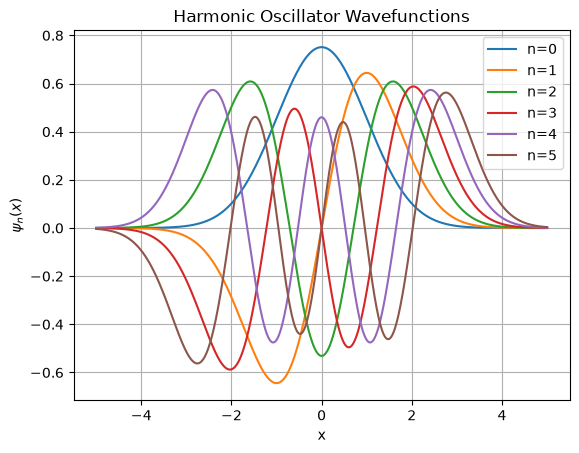

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import hermite , factorial

#Harmonoic oscillator wavefunction
def Psi(n,x,x0=1.0):
    Hn = hermite(n)
    norm = 1.0 / np.sqrt(np.sqrt(np.pi)*(2**n)*factorial(n)*x0)
    return norm * Hn(x/x0)*np.exp(-x**2/(2*x0**2))

x = np.linspace(-5, 5, 1000)

#n until 5
for n in range(6):
    plt.plot(x,Psi(n,x),label=f'n={n}')
plt.title('Harmonic Oscillator Wavefunctions')
plt.xlabel('x')
plt.ylabel(r'$\psi_n(x)$')
plt.legend()
plt.grid()
plt.show()    

# 2. Harmonic density matrix

Partition Function (Z) = 0.9595173756674712


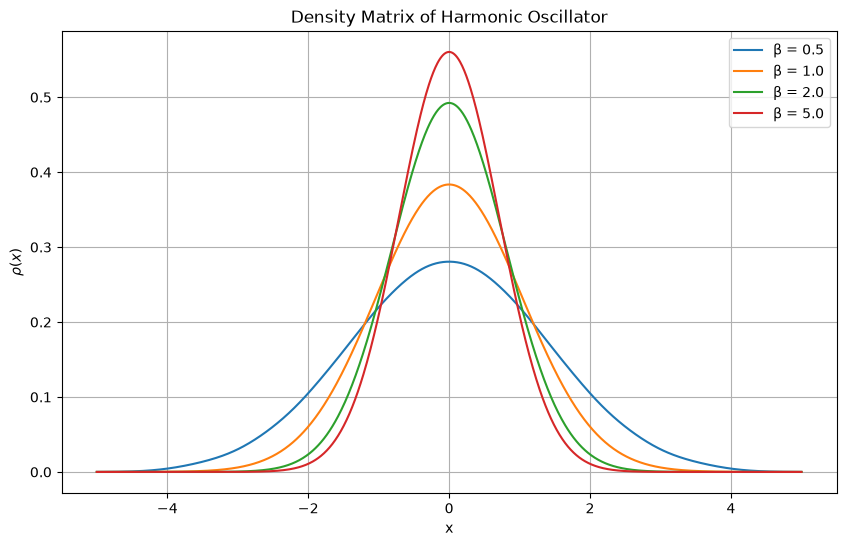

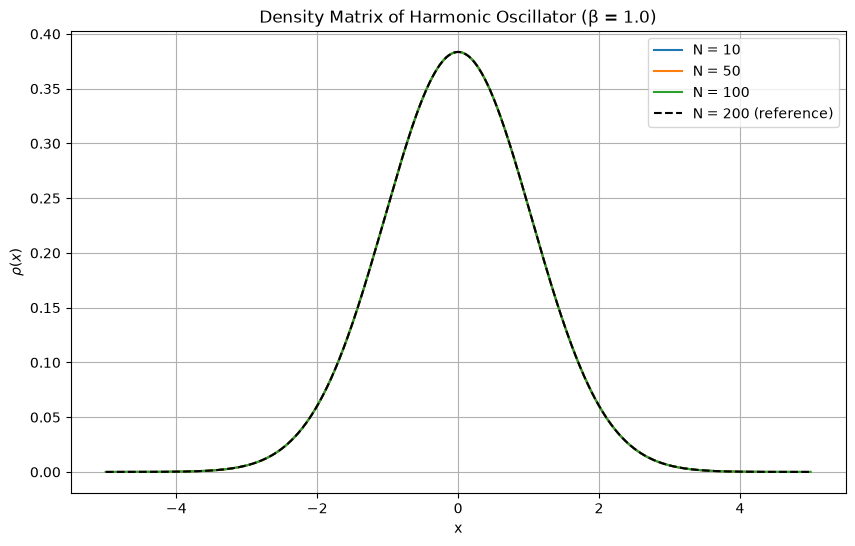

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import hermite, factorial


#Harmonoic oscillator wavefunction
def Psi(n,x,x0=1.0):
    Hn = hermite(n)
    norm = 1.0 / np.sqrt(np.sqrt(np.pi)*(2**n)*factorial(n)*x0)
    return norm * Hn(x/x0)*np.exp(-x**2/(2*x0**2))


# Constants
hbar = 1.0
m = 1.0
omega = 1.0

x0 = np.sqrt(hbar/(m*omega))


# Energy
def Energy(n):

    return hbar * omega * (n + 0.5)


# Partition function
def Z(beta, nmax):

    return sum(np.exp(-beta * Energy(i)) for i in range(nmax))


# Probability
def P(n, beta, nmax):

    return np.exp(-beta * Energy(n)) / Z(beta, nmax)


#density matrix
def density_matrix(nmax, x, beta):

    rho = np.zeros_like(x)

    for i in range(nmax):

        weight = np.exp(-beta * Energy(i))

        if weight < 1e-12:
            break

        rho += (weight / Z(beta, nmax)) * Psi(i, x, x0)**2

    return rho


x = np.linspace(-5, 5, 1000)
betas = [0.5, 1.0, 2.0, 5.0]

plt.figure(figsize=(10,6))

for beta in betas:
    rho = density_matrix(10, x, beta)
    plt.plot(x, rho, label=f"β = {beta}")

plt.title("Density Matrix of Harmonic Oscillator")
plt.xlabel("x")
plt.ylabel(r"$\rho(x)$")
plt.grid(True)
plt.legend()



beta = 1.0
N = 100
Z_value = Z(beta, N)

print("Partition Function (Z) =", Z_value)

# density matrix for different N values
N_values = [10, 50, 100]

plt.figure(figsize=(10,6))

for N in N_values:

    rho = density_matrix(N, x, beta)
    plt.plot(x, rho, label=f"N = {N}")

plt.plot(x, density_matrix(1000, x, beta), 'k--', label='N = 200 (reference)')
plt.title(f"Density Matrix of Harmonic Oscillator (β = {beta})")
plt.xlabel("x")
plt.ylabel(r"$\rho(x)$")
plt.grid(True)
plt.legend()

plt.show()

# 3) Free particles

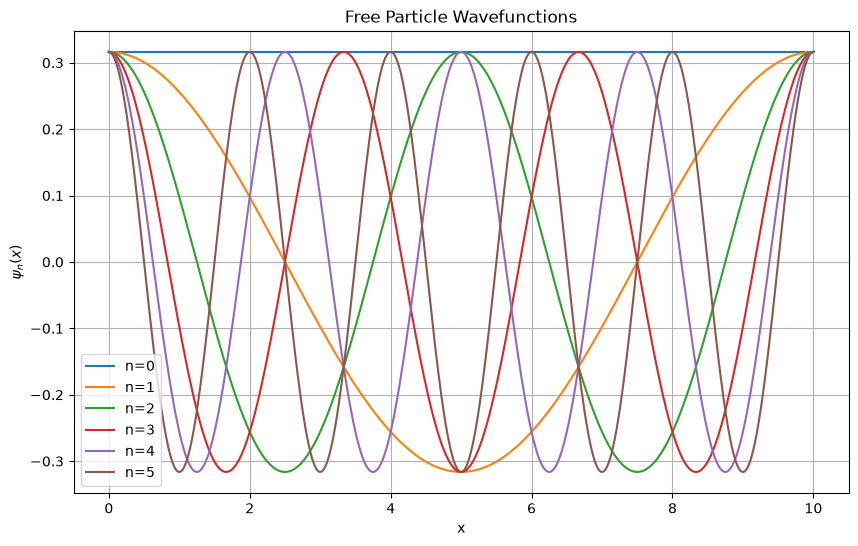

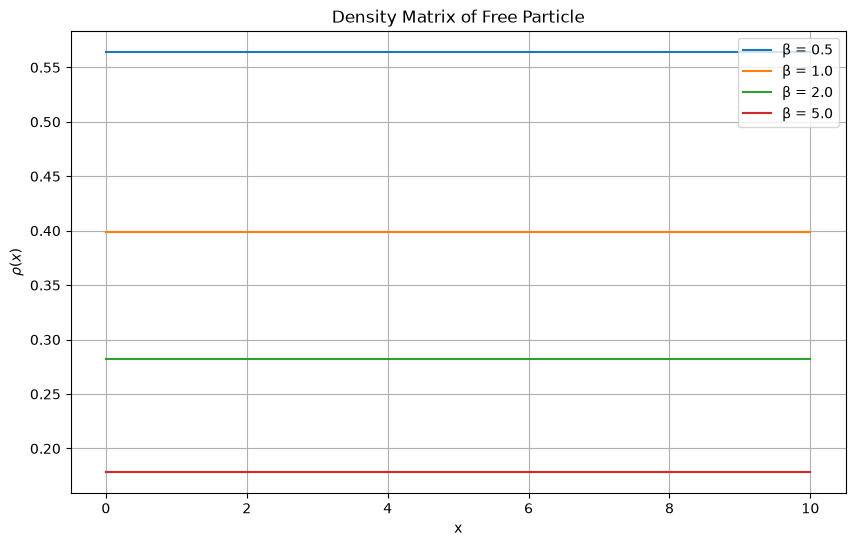

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import hermite, factorial

#constants
hbar = 1.0
m = 1.0
L= 10.0

#free particle wavefunction (consider reaL part only)
def Psi_free(n, x, L):
    k = 2* np.pi*n/L
    norm = np.sqrt(1/L)
    return norm * np.cos(k*x)




x = np.linspace(0, L, 1000)

plt.figure(figsize=(10,6))
for n in range(6):
    plt.plot(x, Psi_free(n, x, L), label=f'n={n}')
plt.title('Free Particle Wavefunctions')
plt.xlabel('x')
plt.ylabel(r'$\psi_n(x)$')
plt.legend()
plt.grid()
plt.show()


#density matrix for free particle
def density_matrix_free(x, beta, L, nmax =100):
    rho = np.zeros_like(x)
  

    for i in range(-nmax, nmax+1):
        k = 2* np.pi*i/L
        E = (hbar**2 * k**2)/(2*m)

        rho += np.exp(-beta * E) / L

    return rho

betas = [0.5, 1.0, 2.0, 5.0]

plt.figure(figsize=(10,6))
for beta in betas:
    rho = density_matrix_free(x, beta, L)
    plt.plot(x, rho, label=f"β = {beta}")
plt.title("Density Matrix of Free Particle")
plt.xlabel("x") 
plt.ylabel(r'$\rho(x)$')
plt.legend()
plt.grid()
plt.show()

# 4) Harmonic oscillator

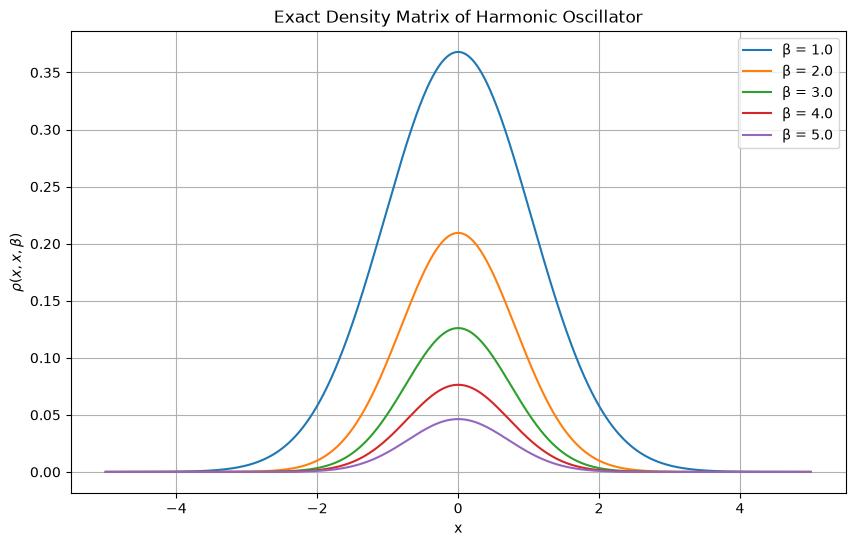

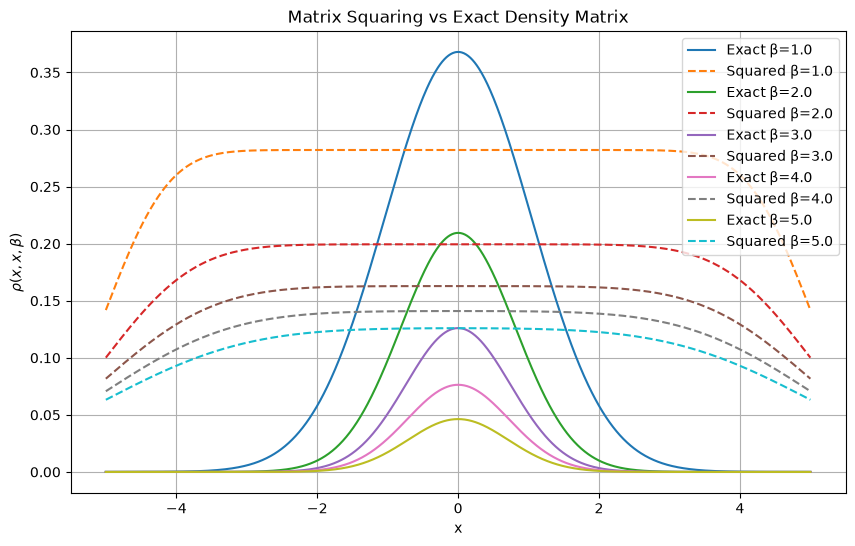

In [9]:
import numpy as np
import matplotlib.pyplot as plt


# Constants
hbar = 1.0
m = 1.0
omega = 1.0


def density_matrix_squaring(x, beta):

    dx = x[1] - x[0]
    n = len(x)
    rho = np.zeros((n, n))

    for i in range(n):
        for j in range(n):

            diff = x[i] - x[j]
            rho[i,j] = np.sqrt(m/(2*np.pi*hbar*beta)) * np.exp(-m*diff**2/(2*hbar*beta))

    return rho


def matrix_square(rho, dx):
    return np.dot(rho, rho) * dx



def exact_density(x, beta):
    return np.sqrt(1/(2*np.pi*np.sinh(beta))) * np.exp(-x**2*np.tanh(beta/2))



x = np.linspace(-5, 5, 1000)
betas = [1.0, 2.0, 3.0, 4.0, 5.0]


plt.figure(figsize=(10,6))

for beta in betas:
    rho_exact = exact_density(x, beta)
    plt.plot(x, rho_exact, label=f"β = {beta}")

plt.xlabel("x")
plt.ylabel(r"$\rho(x,x,\beta)$")
plt.title("Exact Density Matrix of Harmonic Oscillator")
plt.grid(True)
plt.legend()

plt.show()



# Matrix squaring vs exact
plt.figure(figsize=(10,6))

for beta in betas:

    rho_exact = exact_density(x, beta)
    rho = density_matrix_squaring(x, beta)
    dx = x[1] - x[0]
    rho_sq = matrix_square(rho, dx)

    plt.plot(x, rho_exact,label=f"Exact β={beta}")
    plt.plot(x, rho_sq.diagonal(),'--',label=f"Squared β={beta}")


plt.xlabel("x")
plt.ylabel(r"$\rho(x,x,\beta)$")
plt.title("Matrix Squaring vs Exact Density Matrix")
plt.grid(True)
plt.legend()

plt.show()